## 신용카드 사기 검출 분류 데이터셋
* 레이블 Class 속성이 매우 불균형한 분포 가짐
  * 0=정상적 신용카드 트랜잭션 데이터, 1=사기 트랜잭션

## 언더 샘플링과 오버 샘플링의 이해
* 불균형 분포 가진 데이터 셋은 이상 레이블은 데이터 건수가 매우 적음 -> 다양한 유형 학습 힘듦 -> 예측 성능 문제 발생
* 적절한 학습 데이터 확보하기 위해 오버 샘플링/언더 샘플링 사용 -> 오버 샘플링이 예측 성능상 더 유리
* 언더 샘플링(undersampling)
  * 많은 레이블을 가진 데이터셋을 적은 레이블을 가지는 데이터셋 수준으로 감소시킴
  * 과도하게 '많은 레이블'로 학습/예측하는 부작용 개선
  * 오히려 '많은 레이블'을 제대로 학습 안되기도 함(줄여버려서)
* 오버 샘플링(Oversampling)
  * 이상 데이터와 같이 적은 데이터셋을 증식하여 학습 위한 충분하 데이터를 확보
  * 동일한 데이터를 단순 증식시키면 과적합 됨, 의미 없음 -> 원본 데이터의 피처 값을 아주 약간만 변형해 증식
  * SMOTE(Synthetic mIniority over-sampling technique) 방법이 대표적 -> imbalanced-learn 파이썬 패키지
    * 적은 데이터셋의 개별 데이터들의 K 최근접이웃(K nearest neighbors) 찾아
    * 이 데이터와 K개 이웃 사이의 차이를 일정 값으로 만들어 
    * 기존 데이터와 약간 차이가 나는 새로운 데이터들을 생성

## 데이터 일차 가공

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

card_df = pd.read_csv('../kaggle/creditcard_fraud/creditcard.csv')
card_df.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


* Time 피처는 데이터 생성 관련 작업용 속성 -> 큰 의미 없어 제거
* Amount 피처는 트랙잭션 금액 -> class는 0이 정상, 1이 사기
* info()로 보면 결측치 없고 class 만 int, 나머지는 float

In [14]:
# 데이서 사전 가공, 예측 성능 비교

from sklearn.model_selection import train_test_split

def get_preprocessed_df(df=None):
    df_copy = df.copy()
    df_copy.drop('Time', axis=1, inplace=True)
    return df_copy

def get_train_test_dataset(df=None):
    df_copy = get_preprocessed_df(df)
    x_features = df_copy.iloc[:, :-1]
    y_target = df_copy.iloc[:, -1]
    x_train, x_test, y_train, y_test = train_test_split(x_features, y_target, test_size=0.3, random_state=0, stratify=y_target)
    return x_train, x_test, y_train, y_test

x_train, x_test, y_train, y_test = get_train_test_dataset(card_df)

print('학습 데이터 레이블 값 비율')
print(y_train.value_counts()/y_train.shape[0] * 100)
print('테스트 데이터 레이블 값 비율')
print(y_test.value_counts()/y_test.shape[0] * 100)

학습 데이터 레이블 값 비율
0    99.827451
1     0.172549
Name: Class, dtype: float64
테스트 데이터 레이블 값 비율
0    99.826785
1     0.173215
Name: Class, dtype: float64


## 로지스틱 회귀 모델 학습/평가

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred_proba)
    
    print('오차행렬 : ')
    print(confusion)
    
    print('정확도 : {0:.4f} , 정밀도 : {1:.4f} , 재현율 : {2:.4f} , F1 : {3:.4f} , AUC : {4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))


In [5]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression()
lr_clf.fit(x_train, y_train)
lr_pred = lr_clf.predict(x_test)
lr_pred_proba = lr_clf.predict_proba(x_test)[:, 1]

get_clf_eval(y_test, lr_pred, lr_pred_proba)

오차행렬 : 
[[85282    13]
 [   56    92]]
정확도 : 0.9992 , 정밀도 : 0.8762 , 재현율 : 0.6216 , F1 : 0.7273 , AUC : 0.9582


## LightGBM 모델 학습/평가

In [6]:
def get_model_train_eval(model, ftr_train=None, ftr_test=None, tgt_train=None, tgt_test=None):
    model.fit(ftr_train, tgt_train)
    pred = model.predict(ftr_test)
    pred_proba = model.predict_proba(ftr_test)[:, 1]
    get_clf_eval(tgt_test, pred, pred_proba)

In [7]:
from lightgbm import LGBMClassifier

lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
  # 레이블이 분균형하므로 boost_from_average를 False로 설정
get_model_train_eval(lgbm_clf, ftr_train=x_train, ftr_test=x_test, tgt_train=y_train, tgt_test=y_test)

오차행렬 : 
[[85290     5]
 [   36   112]]
정확도 : 0.9995 , 정밀도 : 0.9573 , 재현율 : 0.7568 , F1 : 0.8453 , AUC : 0.9790


## 데이터 분포도 변환 후 모델 학습/예측/평가
* 왜곡된 분포도를 가지는 데이터를 재가공한 뒤 모델 테스트 해보기
* StandardScaler, 로그 변환 각각 사용
* 사용할 로지스틱 회귀는 선형 모델 -> 중요 피처값이 정규 분포 형태인 것을 선호
* 로그 변환
  * 데이터 분포도가 심각학 왜곡되었을 때 적용하는 중요 기법 중 하나
  * 원래 값을 로그로 변환 -> 큰 값을 상대적으로 작게 -> 왜곡 개선
  * 넘파이 log1p()함수 이용

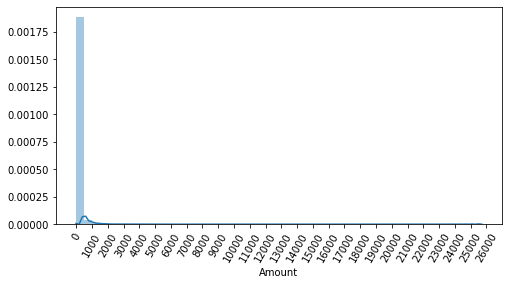

In [9]:
# 중요 피처 값 분포도

import seaborn as sns

plt.figure(figsize=(8, 4))
plt.xticks(range(0, 30000, 1000), rotation=60)
sns.distplot(card_df['Amount'])

In [16]:
# Amount를 표준 정규 분포 형태로 변환한 뒤 예측 성능 측정 -> StandardScaler

from sklearn.preprocessing import StandardScaler

def get_preprocessed_df(df=None):
    df_copy = df.copy()
    scaler = StandardScaler()
    amount_n = scaler.fit_transform(df_copy['Amount'].values.reshape(-1, 1))
    df_copy.insert(0, 'Amount_Scaled', amount_n) #변환된 amount를 피처명 변경한 후 DF의 맨 앞 컬럼으로 설정
    df_copy.drop(['Time', 'Amount'], axis=1, inplace=True)
    return df_copy

In [17]:
x_train, x_test, y_train, y_test = get_train_test_dataset(card_df)

print("***로지스틱 회귀 예측 성능***")
lr_clf = LogisticRegression()
get_model_train_eval(lr_clf, ftr_train=x_train, ftr_test=x_test, tgt_train=y_train, tgt_test=y_test)

print("***LightGBM 예측 성능***")
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1)
get_model_train_eval(lgbm_clf, ftr_train=x_train, ftr_test=x_test, tgt_train=y_train, tgt_test=y_test)

***로지스틱 회귀 예측 성능***
오차행렬 : 
[[85281    14]
 [   58    90]]
정확도 : 0.9992 , 정밀도 : 0.8654 , 재현율 : 0.6081 , F1 : 0.7143 , AUC : 0.9702
***LightGBM 예측 성능***
오차행렬 : 
[[85248    47]
 [   69    79]]
정확도 : 0.9986 , 정밀도 : 0.6270 , 재현율 : 0.5338 , F1 : 0.5766 , AUC : 0.7666


In [18]:
# 로그 변환

def get_preprocessed_df(df=None):
    df_copy = df.copy()
    amount_n = np.log1p(df_copy['Amount'])
    df_copy.insert(0, 'Amount_Scaled', amount_n) #변환된 amount를 피처명 변경한 후 DF의 맨 앞 컬럼으로 설정
    df_copy.drop(['Time', 'Amount'], axis=1, inplace=True)
    return df_copy

In [19]:
x_train, x_test, y_train, y_test = get_train_test_dataset(card_df)

print("***로지스틱 회귀 예측 성능***")
lr_clf = LogisticRegression()
get_model_train_eval(lr_clf, ftr_train=x_train, ftr_test=x_test, tgt_train=y_train, tgt_test=y_test)

print("***LightGBM 예측 성능***")
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1)
get_model_train_eval(lgbm_clf, ftr_train=x_train, ftr_test=x_test, tgt_train=y_train, tgt_test=y_test)

***로지스틱 회귀 예측 성능***
오차행렬 : 
[[85283    12]
 [   59    89]]
정확도 : 0.9992 , 정밀도 : 0.8812 , 재현율 : 0.6014 , F1 : 0.7149 , AUC : 0.9727
***LightGBM 예측 성능***
오차행렬 : 
[[85174   121]
 [  148     0]]
정확도 : 0.9969 , 정밀도 : 0.0000 , 재현율 : 0.0000 , F1 : 0.0000 , AUC : 0.4992


## 이상치 데이터 제거 후 모델 학습/예측/평가
* 이상치 데이터(outlier) : 전체 테이터 패턴에서 벗어난 이상 값을 가진 데이터(=아웃라이어) -> ML 모델 성능에 영향 받는 경우 발생
* IQR(Inter Quantile Range) 방식
  * 이상치 데이터 찾는 방법 중 하나. 
  * 사분위(Quantile) 값의 편차 이용
    * 사분위 : 전체 데이터를 값이 높은 순으로 정렬 -> 1/4씩으로 구간(Q) 분할하는 것
    * 0 ~ Q1 ~ Q2 ~ Q3 ~ Q4(100%)
    * IQR = Q1부터 Q3까지. 25~75%까지의 구간
    * IQR에 보통 1.5를 곱해 생성된 범위 -> 최댓값과 최솟값 결정 -> 최댓값 초과 / 최솟값 미달 데이터를 이상치로 간주 
  * Box Plot 방식으로 시각화 가능
* 어떤 피처 이상치 데이터를 검출할 것인가 결정 -> 여러 피처 있을 땐 결정값(레이블)과 상관성 높은 피처 위주로 이상치 검출해야

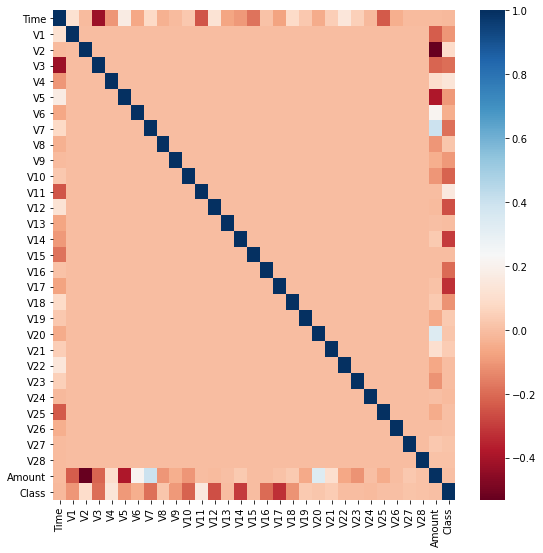

In [20]:
# DataFrame의 corr()로 피처별 상관도 구함 -> 시본 heatmap으로 시각화

import seaborn as sns

plt.figure(figsize=(9, 9))
corr = card_df.corr()
sns.heatmap(corr, cmap="RdBu") #양의 상관관계가 높을 수록 진한 파랑에 가까움. 음의 상관관계 높을 수록 진한 빨강

In [23]:
# Class 피처와 음의 상관관계 높은 V14, V17 중 V14대해 이상치 찾아 제거
# IQR 이용해 이상치 검출하는 함수 생성 -> 이상치 삭제

import numpy as np

def get_outlier(df=None, column=None, weight=1.5):
    #fraud에 해당하는 컬럼 데이터만 추출. 1/4와 3/4 분위 지점을 np.percentle로 구함
    fraud=df[df['Class']==1][column]
    q_25 = np.percentile(fraud.values, 25)
    q_75 = np.percentile(fraud.values, 75)
    #IQR구하고 1.5 곱해 최대/최솟값 지점 구함
    iqr = q_75 - q_25
    iqr_weight = iqr * weight
    lowest_val = q_25 - iqr_weight
    highest_val = q_75 + iqr_weight
    #이상치 데이터 골라내고 DF index 변환
    outlier_index = fraud[(fraud < lowest_val)|(fraud > highest_val)].index
    return outlier_index

outlier_index = get_outlier(df=card_df, column="V14", weight=1.5)
print('이상치 데이터 인덱스 : ', outlier_index)

이상치 데이터 인덱스 :  Int64Index([8296, 8615, 9035, 9252], dtype='int64')


In [24]:
# 로그변환 + 이상치 데이터 삭제 로직으로 함수 변경

def get_preprocessed_df(df=None):
    df_copy = df.copy()
    amount_n = np.log1p(df_copy['Amount'])
    df_copy.insert(0, 'Amount_Scaled', amount_n) #변환된 amount를 피처명 변경한 후 DF의 맨 앞 컬럼으로 설정
    df_copy.drop(['Time', 'Amount'], axis=1, inplace=True)
    outlier_index = get_outlier(df=df_copy, column='V14', weight=1.5)
    df_copy.drop(outlier_index, axis=0, inplace=True)
    return df_copy

x_train, x_test, y_train, y_test = get_train_test_dataset(card_df)

print("***로지스틱 회귀 예측 성능***")
lr_clf = LogisticRegression()
get_model_train_eval(lr_clf, ftr_train=x_train, ftr_test=x_test, tgt_train=y_train, tgt_test=y_test)

print("***LightGBM 예측 성능***")
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1)
get_model_train_eval(lgbm_clf, ftr_train=x_train, ftr_test=x_test, tgt_train=y_train, tgt_test=y_test)

***로지스틱 회귀 예측 성능***
오차행렬 : 
[[85281    14]
 [   48    98]]
정확도 : 0.9993 , 정밀도 : 0.8750 , 재현율 : 0.6712 , F1 : 0.7597 , AUC : 0.9743
***LightGBM 예측 성능***
오차행렬 : 
[[85268    27]
 [   36   110]]
정확도 : 0.9993 , 정밀도 : 0.8029 , 재현율 : 0.7534 , F1 : 0.7774 , AUC : 0.9219


## SMOTE 오버 샘플링 적용 후 모델 학습/예측/평가
* imbalanced-learn 패키지 SMOTE 클래스
* 반드시 학습 데이터셋만 오버 샘프링 해야 함 -> 검증이나 테스트 셋 (X)

In [26]:
# SMOTE 객체의 fit_sample() 메서드로 데이터 증식한 뒤 전과 비교

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=0)
x_train_over, y_train_over = smote.fit_sample(x_train, y_train)
print('SMOTE 전 학습용 피처/레이블 데이터셋 : ', x_train.shape, y_train.shape)
print('SMOTE 후 학습용 피처/레이블 데이터셋 : ', x_train_over.shape, y_train_over.shape)
print('SMOTE 후 레이블 값 분포 : \n', pd.Series(y_train_over).value_counts())

SMOTE 전 학습용 피처/레이블 데이터셋 :  (199362, 29) (199362,)
SMOTE 후 학습용 피처/레이블 데이터셋 :  (398040, 29) (398040,)
SMOTE 후 레이블 값 분포 : 
 1    199020
0    199020
Name: Class, dtype: int64


In [27]:
# 로지스틱 회귀에 적용

lr_clf = LogisticRegression()
get_model_train_eval(lr_clf, ftr_train=x_train_over, ftr_test=x_test, tgt_train=y_train_over, tgt_test=y_test)

오차행렬 : 
[[82937  2358]
 [   11   135]]
정확도 : 0.9723 , 정밀도 : 0.0542 , 재현율 : 0.9247 , F1 : 0.1023 , AUC : 0.9737


* 로지스틱 회귀 모델의 경우, SMOTE 오버샘플링 데이터로 학습뒤 재현율 크게 올랐으나 정밀도 급격히 저하됨 -> 현실 업무 적용 불가
* 실제 테스트 데이터셋에서 예측을 지나치게 class=1로 적용해서
* 분류 결정 임곗값에 따른 정밀도와 재현율 곡선을 시각적으로 확인하자(3장 함수 사용)

ValueError: only 2 non-keyword arguments accepted

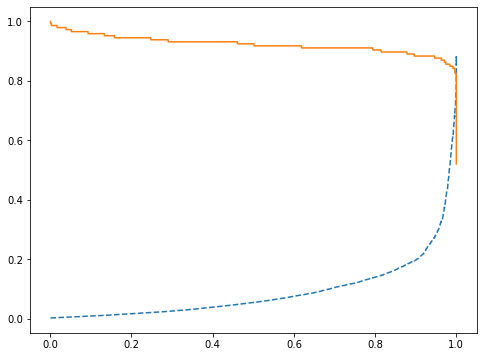

In [29]:
### precision_recall_curve() API의 시각화

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

def precision_recall_curve_plot(y_test, pred_proba_c1):
    #threshold ndarray와 이 threshold에 따른 정밀도, 재현율 ndarray 추출
    precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_c1)
    #x축을 threshold값으로, y축을 정밀도, 재현율 값으로 각각 plot 수행. 정밀도는 점선
    plt.figure(figsize=(8, 6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary], label='recall')
    #threshold값 x축의 스케일을 0.1 단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.array(start, end, 0.1), 2))
    #각 축 라벨과 범례, 그리드 설정
    plt.xlabel("Threshold value")
    plt.ylabel("Precision and Recall Value")
    plt.legend()
    plt.grid()
    plt.show()

precision_recall_curve_plot(y_test, lr_clf.predict_proba(x_test)[:,1])

* 0.99 임곗값 이상/이하에서 민감도 너무 심해 올바른 성능 얻을 수 없음 -> 임곗값 조정하더라도 불가

In [30]:
# Light GBM에 적용

lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1)
get_model_train_eval(lgbm_clf, ftr_train=x_train_over, ftr_test=x_test, tgt_train=y_train_over, tgt_test=y_test)

오차행렬 : 
[[85283    12]
 [   22   124]]
정확도 : 0.9996 , 정밀도 : 0.9118 , 재현율 : 0.8493 , F1 : 0.8794 , AUC : 0.9814


* 재현율은 이상치만 제거했을 때보단 높아졌으나, 정밀도는 낮아짐
* SMOTE 적용 시 재현율은 높아지고 정밀도는 낮아지는 것이 일반적 -> 좋은 SMOTE 패키지일수록 재현율 증가율은 높이고 정밀도 감소율은 낮춤